# Pandas: Reshaping and cleaning data

## Slicing & dicing

We import the same csv file about restaurant orders and load the data into a dataframe.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv', sep='\t')

If we want to slice characters, we first need to access the string object in the dataframe. We can apply a function on the dataframe to repeat the instruction to all data rows on a particular column.

In [3]:
def convert_price_string_to_float(txt):
    return float(txt[1:])

df['item_price'] = df['item_price'].apply(convert_price_string_to_float)

Slices can be made by using the squared brackets [ ], using a start index and a stop index value, seperated by a : symbol as pandas assumes you want to slice by position.

In [4]:
df[0:3]

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,2.39
1,1,1,Izze,[Clementine],3.39
2,1,1,Nantucket Nectar,[Apple],3.39


In [5]:
df.head()

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,2.39
1,1,1,Izze,[Clementine],3.39
2,1,1,Nantucket Nectar,[Apple],3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",16.98


The syntax of the slicing function is start:stop:step, with the second colon : and arguments optional, the same as for Python’s built-in slicing. The default start value is the beginning of the series, the default stop value is one past the end, and the default step value is 1.

In [6]:
x = pd.Series([10, 20, 30, 40, 50, 60, 70, 80, 90, 100], index = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
print(x)

1      10
2      20
3      30
4      40
5      50
6      60
7      70
8      80
9      90
10    100
dtype: int64


If we leave out the start and stop value, defaults are taken. The step argument will skip rows based on the step value.

In [7]:
x[1::2]

2      20
4      40
6      60
8      80
10    100
dtype: int64

We can also take slices by going backwards in the data. To do that, we use negative indexes.

In [8]:
x[-2:]

9      90
10    100
dtype: int64

Slicing by can also be done with indexes of type string. Then it slices when the string index is found in the series.

In [9]:
x = pd.Series([10, 20, 30, 40, 50, 60, 70, 80, 90, 100], index = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j'])
print(x)

a     10
b     20
c     30
d     40
e     50
f     60
g     70
h     80
i     90
j    100
dtype: int64


In [10]:
print(x['c':])

c     30
d     40
e     50
f     60
g     70
h     80
i     90
j    100
dtype: int64


For a specific position, independent of the index data type (e.g., when it's a string) we can use .iloc[position]

In [11]:
print(x.iloc[7])
print(x['h'])

80
80


We can also slice using conditions:

In [12]:
print(x[x > 20])

c     30
d     40
e     50
f     60
g     70
h     80
i     90
j    100
dtype: int64


When we use dataframes instead of series:

In [13]:
df.head(3) 

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,2.39
1,1,1,Izze,[Clementine],3.39
2,1,1,Nantucket Nectar,[Apple],3.39


In [14]:
df[0:2]['item_price']  ## alternatively?

0    2.39
1    3.39
Name: item_price, dtype: float64

In [15]:
df['item_price'][0:2]

0    2.39
1    3.39
Name: item_price, dtype: float64

In [16]:
df.loc[[0,1], 'item_price']

0    2.39
1    3.39
Name: item_price, dtype: float64

In [18]:
df.iloc[0:2, 4]

0    2.39
1    3.39
Name: item_price, dtype: float64

"The main difference between slice and dice in data warehouse is that the slice is an operation that selects one specific dimension from a given data cube and provides a new subcube while the dice is an operation that selects two or more dimensions from a given data cube and provides a new subcube" (source [link](https://pediaa.com/what-is-the-difference-between-slice-and-dice-in-data-warehouse/))

## Concat, Append, Merge & Join

### Concatenation

Let's create some data frames that we can glue together. If we concatenate, we can do that by using keys from the column or the rows. In python, we call these the axis. By default, we concatenate rows by matching columns.

In [19]:
df4 = pd.DataFrame(
    {
        "A": ["A0", "A1", "A2", "A3"],
        "B": ["B0", "B1", "B2", "B3"],
        "C": ["C0", "C1", "C2", "C3"],
        "D": ["D0", "D1", "D2", "D3"],
    },
    index=[0, 1, 2, 3],
)

df5 = pd.DataFrame(
    {
        "A": ["A4", "A5", "A6", "A7"],
        "B": ["B4", "B5", "B6", "B7"],
        "D": ["D4", "D5", "D6", "D7"],
    },
    index=[3, 5, 6, 7],  ##
)

df6 = pd.DataFrame(
    {
        "A": ["A8", "A9", "A10"],
        "B": ["B8", "B9", "B10"],
        "E": ["E8", "E9", "E10"]
    },
    index=[8, 9, 10],
)

In [20]:
print("df4:"); print(df4); print('\n')
print("df5:"); print(df5); print('\n')
print("df6:"); print(df6)

df4:
    A   B   C   D
0  A0  B0  C0  D0
1  A1  B1  C1  D1
2  A2  B2  C2  D2
3  A3  B3  C3  D3


df5:
    A   B   D
3  A4  B4  D4
5  A5  B5  D5
6  A6  B6  D6
7  A7  B7  D7


df6:
      A    B    E
8    A8   B8   E8
9    A9   B9   E9
10  A10  B10  E10


In [21]:
frames = [df4, df5, df6]
result1 = pd.concat(frames)  
print(result1)

      A    B    C    D    E
0    A0   B0   C0   D0  NaN
1    A1   B1   C1   D1  NaN
2    A2   B2   C2   D2  NaN
3    A3   B3   C3   D3  NaN
3    A4   B4  NaN   D4  NaN
5    A5   B5  NaN   D5  NaN
6    A6   B6  NaN   D6  NaN
7    A7   B7  NaN   D7  NaN
8    A8   B8  NaN  NaN   E8
9    A9   B9  NaN  NaN   E9
10  A10  B10  NaN  NaN  E10


In [22]:
frames = [df4, df5, df6]
result1 = pd.concat(frames, ignore_index=True)
print(result1)

      A    B    C    D    E
0    A0   B0   C0   D0  NaN
1    A1   B1   C1   D1  NaN
2    A2   B2   C2   D2  NaN
3    A3   B3   C3   D3  NaN
4    A4   B4  NaN   D4  NaN
5    A5   B5  NaN   D5  NaN
6    A6   B6  NaN   D6  NaN
7    A7   B7  NaN   D7  NaN
8    A8   B8  NaN  NaN   E8
9    A9   B9  NaN  NaN   E9
10  A10  B10  NaN  NaN  E10


Differences between joins (inner, outer (left, right, full))

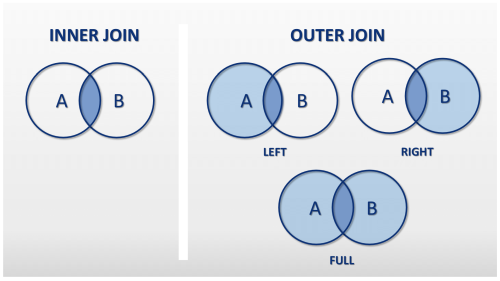

If we would like to concatenate columns, by matching index of the row, we use the parameter *axis=1*. This join is by default an outer join.

In [23]:
frames = [df4, df5, df6]
result2 = pd.concat(frames, axis=1)  
print(result2)

      A    B    C    D    A    B    D    A    B    E
0    A0   B0   C0   D0  NaN  NaN  NaN  NaN  NaN  NaN
1    A1   B1   C1   D1  NaN  NaN  NaN  NaN  NaN  NaN
2    A2   B2   C2   D2  NaN  NaN  NaN  NaN  NaN  NaN
3    A3   B3   C3   D3   A4   B4   D4  NaN  NaN  NaN
5   NaN  NaN  NaN  NaN   A5   B5   D5  NaN  NaN  NaN
6   NaN  NaN  NaN  NaN   A6   B6   D6  NaN  NaN  NaN
7   NaN  NaN  NaN  NaN   A7   B7   D7  NaN  NaN  NaN
8   NaN  NaN  NaN  NaN  NaN  NaN  NaN   A8   B8   E8
9   NaN  NaN  NaN  NaN  NaN  NaN  NaN   A9   B9   E9
10  NaN  NaN  NaN  NaN  NaN  NaN  NaN  A10  B10  E10


In [24]:
result2 = pd.concat(frames, axis=1, ignore_index=True)  
print(result2)

      0    1    2    3    4    5    6    7    8    9
0    A0   B0   C0   D0  NaN  NaN  NaN  NaN  NaN  NaN
1    A1   B1   C1   D1  NaN  NaN  NaN  NaN  NaN  NaN
2    A2   B2   C2   D2  NaN  NaN  NaN  NaN  NaN  NaN
3    A3   B3   C3   D3   A4   B4   D4  NaN  NaN  NaN
5   NaN  NaN  NaN  NaN   A5   B5   D5  NaN  NaN  NaN
6   NaN  NaN  NaN  NaN   A6   B6   D6  NaN  NaN  NaN
7   NaN  NaN  NaN  NaN   A7   B7   D7  NaN  NaN  NaN
8   NaN  NaN  NaN  NaN  NaN  NaN  NaN   A8   B8   E8
9   NaN  NaN  NaN  NaN  NaN  NaN  NaN   A9   B9   E9
10  NaN  NaN  NaN  NaN  NaN  NaN  NaN  A10  B10  E10


Take for example another data frame df7 which contains a column E, and some matching indexes with the original df4, we can outer join the columns to existing rows.

In [25]:
df7 = pd.DataFrame(
    {
        "E": ["E0", "E1", "E2", "E3", "E4"],
    },
    index=[0, 1, 2, 3, 4],
)

In [26]:
print("df4:"); print(df4); print('\n')
print("df7:"); print(df7)

df4:
    A   B   C   D
0  A0  B0  C0  D0
1  A1  B1  C1  D1
2  A2  B2  C2  D2
3  A3  B3  C3  D3


df7:
    E
0  E0
1  E1
2  E2
3  E3
4  E4


In [27]:
result3 = pd.concat([df4, df7], axis=1)
print(result3)

     A    B    C    D   E
0   A0   B0   C0   D0  E0
1   A1   B1   C1   D1  E1
2   A2   B2   C2   D2  E2
3   A3   B3   C3   D3  E3
4  NaN  NaN  NaN  NaN  E4


In [28]:
result3 = pd.concat([df4, df5], axis=1)  ## outer join of df4 and df5
print(result3)

     A    B    C    D    A    B    D
0   A0   B0   C0   D0  NaN  NaN  NaN
1   A1   B1   C1   D1  NaN  NaN  NaN
2   A2   B2   C2   D2  NaN  NaN  NaN
3   A3   B3   C3   D3   A4   B4   D4
5  NaN  NaN  NaN  NaN   A5   B5   D5
6  NaN  NaN  NaN  NaN   A6   B6   D6
7  NaN  NaN  NaN  NaN   A7   B7   D7


If we would like to have an inner join, we need to specify this as parameter. An inner join only takes as result the subset of both data frames that have matching indexes.

In [29]:
result4 = pd.concat([df4, df5], axis=1, join="inner")  ## ignore_index=True
print(result4)

    A   B   C   D   A   B   D
3  A3  B3  C3  D3  A4  B4  D4


Sometimes we need to reindex, as the result will otherwise contain missing indexes for smooth iterations.
To obtain a data set that includes at least all the rows of the original dataframe, we can reindex based on this frame.

In [30]:
print(result4.reindex(df5.index))

     A    B    C    D    A    B    D
3   A3   B3   C3   D3   A4   B4   D4
5  NaN  NaN  NaN  NaN  NaN  NaN  NaN
6  NaN  NaN  NaN  NaN  NaN  NaN  NaN
7  NaN  NaN  NaN  NaN  NaN  NaN  NaN


### Append

An append to a data frame is thus basically a concatenation of a dataframe with one Series object.

In [36]:
s1 = pd.Series(["F0", "F1", "F2", "F3"], index=["A", "B", "C", "D"])

result6 = pd.concat([df4, s1.to_frame().T], ignore_index=True)
print(result6)

    A   B   C   D
0  A0  B0  C0  D0
1  A1  B1  C1  D1
2  A2  B2  C2  D2
3  A3  B3  C3  D3
4  F0  F1  F2  F3


In [34]:
print(s1.to_frame())  ## convert the Series s1 into a single-column DataFrame

    0
A  F0
B  F1
C  F2
D  F3


In [37]:
print(s1.to_frame().T)  ##  transpose the DataFrame, i.e., switch rows and columns -> a single-row DataFrame

    A   B   C   D
0  F0  F1  F2  F3


### Merge & Join

The concat function joins based on the index or the row/column labels. Pandas also implemented SQL like functionality of joins.

In [38]:
left = pd.DataFrame(
    {
        "key1": ["K0", "K1", "K2", "K3", "K4"],
        "key2": ["R0", "R1", "R0", "R1", "R2"],
        "A": ["A0", "A1", "A2", "A3", "A4"],
        "B": ["B0", "B1", "B2", "B3", "B4"],

    }
)

right = pd.DataFrame(
    {
        "key1": ["K1", "K0", "K2", "K3", "K5"],
        "key2": ["R0", "R1", "R2", "R1", "R2"],
        "E": [7, 4, 3, None, None]
    }, 
    index=[3, 5, 6, 7, 8]
)

In [39]:
print("left:"); print(left); print('\n')
print("right:"); print(right)

left:
  key1 key2   A   B
0   K0   R0  A0  B0
1   K1   R1  A1  B1
2   K2   R0  A2  B2
3   K3   R1  A3  B3
4   K4   R2  A4  B4


right:
  key1 key2    E
3   K1   R0  7.0
5   K0   R1  4.0
6   K2   R2  3.0
7   K3   R1  NaN
8   K5   R2  NaN


In [40]:
result7 = pd.merge(left, right, on="key1")
print(result7)

  key1 key2_x   A   B key2_y    E
0   K0     R0  A0  B0     R1  4.0
1   K1     R1  A1  B1     R0  7.0
2   K2     R0  A2  B2     R2  3.0
3   K3     R1  A3  B3     R1  NaN


We can also join using multiple keys.

In [41]:
result8 = pd.merge(left, right, on=["key1", "key2"])
print(result8)

  key1 key2   A   B   E
0   K3   R1  A3  B3 NaN


Or join by different merge methods (e.g., left, right, outer, inner)

In [42]:
result9 = pd.merge(left, right, how="inner", on=["key1", "key2"])
print(result9)

  key1 key2   A   B   E
0   K3   R1  A3  B3 NaN


In [43]:
result9 = pd.merge(left, right, how="outer", on=["key1", "key2"])
print(result9)

  key1 key2    A    B    E
0   K0   R0   A0   B0  NaN
1   K0   R1  NaN  NaN  4.0
2   K1   R0  NaN  NaN  7.0
3   K1   R1   A1   B1  NaN
4   K2   R0   A2   B2  NaN
5   K2   R2  NaN  NaN  3.0
6   K3   R1   A3   B3  NaN
7   K4   R2   A4   B4  NaN
8   K5   R2  NaN  NaN  NaN


In [44]:
result9 = pd.merge(left, right, how="right", on=["key1", "key2"])
print(result9)

  key1 key2    A    B    E
0   K1   R0  NaN  NaN  7.0
1   K0   R1  NaN  NaN  4.0
2   K2   R2  NaN  NaN  3.0
3   K3   R1   A3   B3  NaN
4   K5   R2  NaN  NaN  NaN


In [45]:
result9 = pd.merge(left, right, how="left", on=["key1", "key2"])
print(result9)

  key1 key2   A   B   E
0   K0   R0  A0  B0 NaN
1   K1   R1  A1  B1 NaN
2   K2   R0  A2  B2 NaN
3   K3   R1  A3  B3 NaN
4   K4   R2  A4  B4 NaN


When keys from df A and B have different column names.

In [46]:
result9 = pd.merge(left, right, how="left", left_on=["A"], right_on=["key1"])
print(result9)

  key1_x key2_x   A   B key1_y key2_y   E
0     K0     R0  A0  B0    NaN    NaN NaN
1     K1     R1  A1  B1    NaN    NaN NaN
2     K2     R0  A2  B2    NaN    NaN NaN
3     K3     R1  A3  B3    NaN    NaN NaN
4     K4     R2  A4  B4    NaN    NaN NaN


## Pivoting

Pivoting is the reorganization of a data frame by means of aggregation of selected columns values as rows in the new data frame.

In [47]:
df = pd.DataFrame({'Team': ['one', 'one', 'one', 'two', 'two',
                           'two'],
                   'Name': ['Bert', 'Ernie', 'Samson', 'Gert', 'Ernie', 'Alberto'],
                   'Points': [6, 4, 4, 5, 6, 7],
                   'City': ['Sesamstraat', 'Sesamstraat', 'Belgium', 'Belgium', 'Sesamstraat', 'Belgium']})

df

,Team,Name,Points,City
0,one,Bert,6,Sesamstraat
1,one,Ernie,4,Sesamstraat
2,one,Samson,4,Belgium
3,two,Gert,5,Belgium
4,two,Ernie,6,Sesamstraat
5,two,Alberto,7,Belgium


In [48]:
df.pivot(index='Team', columns='Name', values='Points')

Name,Alberto,Bert,Ernie,Gert,Samson
Team,,,,,
one,NaN,6.0,4.0,NaN,4.0
two,7.0,NaN,6.0,5.0,NaN


# Pandas: Data Cleaning

Bad data could be:

 *   Empty cells
 *   Data in wrong format
 *   Wrong data
 *   Duplicates

## Handling missing data

To make detecting missing values easier (and across different array dtypes), pandas provides the *isna()* and *notna()* functions. NaN stands for Not a Number (but means missing number). Different forms exist based on the data type (e.g., NaT, ). Do not confuse with values such as *None*. None is a value that there is no object, usually the return of a function (there was no return value). None is not the same as 0, False, or an empty object.

In [49]:
print(result9); print("\n")
print(pd.isna(result9)); print("\n")
print(result9['A'].notna())

  key1_x key2_x   A   B key1_y key2_y   E
0     K0     R0  A0  B0    NaN    NaN NaN
1     K1     R1  A1  B1    NaN    NaN NaN
2     K2     R0  A2  B2    NaN    NaN NaN
3     K3     R1  A3  B3    NaN    NaN NaN
4     K4     R2  A4  B4    NaN    NaN NaN


   key1_x  key2_x      A      B  key1_y  key2_y     E
0   False   False  False  False    True    True  True
1   False   False  False  False    True    True  True
2   False   False  False  False    True    True  True
3   False   False  False  False    True    True  True
4   False   False  False  False    True    True  True


0    True
1    True
2    True
3    True
4    True
Name: A, dtype: bool


For some calculations, it may be nessecary to have values, even though these were initially not provided. Think about aggregating a column value on price. To replace missing values, one could use the function *fillna()*.

In [50]:
# pd.set_option('future.no_silent_downcasting', True)
result9_1 = result9.fillna(0)
print(result9_1)

  key1_x key2_x   A   B  key1_y  key2_y    E
0     K0     R0  A0  B0       0       0  0.0
1     K1     R1  A1  B1       0       0  0.0
2     K2     R0  A2  B2       0       0  0.0
3     K3     R1  A3  B3       0       0  0.0
4     K4     R2  A4  B4       0       0  0.0


C:\Users\orrru\AppData\Local\Temp\ipykernel_3640\1734462336.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  result9_1 = result9.fillna(0)


In [51]:
print(result9)

  key1_x key2_x   A   B key1_y key2_y   E
0     K0     R0  A0  B0    NaN    NaN NaN
1     K1     R1  A1  B1    NaN    NaN NaN
2     K2     R0  A2  B2    NaN    NaN NaN
3     K3     R1  A3  B3    NaN    NaN NaN
4     K4     R2  A4  B4    NaN    NaN NaN


Missing value's can be interpreted as zero as they were intended as such (different represenation), but it might also mean a data entry was unintentionally missing. In such cases, you might better interpolate what that data probably should have been.

In [58]:
import numpy as np
# result9 = pd.merge(left, right, how="left", left_on=["A"], right_on=["key1"])
result9['E'][0] = 5
result9['E'][1] = np.nan  ## a missing value
print(result9)

result10 = result9.fillna(result9['E'].mean())
print(result10)

  key1_x key2_x   A   B key1_y key2_y    E
0     K0     R0  A0  B0    NaN    NaN  5.0
1     K1     R1  A1  B1    NaN      1  NaN
2     K2     R0  A2  B2    NaN    NaN  NaN
3     K3     R1  A3  B3    NaN    NaN  NaN
4     K4     R2  A4  B4    NaN    NaN  NaN
  key1_x key2_x   A   B  key1_y  key2_y    E
0     K0     R0  A0  B0     5.0     5.0  5.0
1     K1     R1  A1  B1     5.0     1.0  5.0
2     K2     R0  A2  B2     5.0     5.0  5.0
3     K3     R1  A3  B3     5.0     5.0  5.0
4     K4     R2  A4  B4     5.0     5.0  5.0


C:\Users\orrru\AppData\Local\Temp\ipykernel_3640\3407721518.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  result9['E'][0] = 5
C:\Users\orrru\AppData\Local\Temp\ipykernel_3640\3407721518.py:3: SettingWithCopyWarning: 
A value is trying 

In [54]:
import numpy as np
# result9 = pd.merge(left, right, how="left", left_on=["A"], right_on=["key1"])
result9.loc[0, 'E'] = 5       ## use .loc[] to suppress the warning
result9.loc[1, 'E'] = np.nan  ## use .loc[] to suppress the warning 
result9.loc[1, 'key2_y'] = 1
print(result9, "\n")

result10 = result9.fillna(result9['E'].mean())  ## to solve the error
print(result10)

  key1_x key2_x   A   B key1_y key2_y    E
0     K0     R0  A0  B0    NaN    NaN  5.0
1     K1     R1  A1  B1    NaN      1  NaN
2     K2     R0  A2  B2    NaN    NaN  NaN
3     K3     R1  A3  B3    NaN    NaN  NaN
4     K4     R2  A4  B4    NaN    NaN  NaN 

  key1_x key2_x   A   B  key1_y  key2_y    E
0     K0     R0  A0  B0     5.0     5.0  5.0
1     K1     R1  A1  B1     5.0     1.0  5.0
2     K2     R0  A2  B2     5.0     5.0  5.0
3     K3     R1  A3  B3     5.0     5.0  5.0
4     K4     R2  A4  B4     5.0     5.0  5.0


C:\Users\orrru\AppData\Local\Temp\ipykernel_3640\2179489505.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  result10 = result9.fillna(result9['E'].mean())  ## to solve the error


## Drop certain data: the *drop()* function

In [75]:
df5 = pd.DataFrame(
    {
        "A": ["A4", "A5", "A6", "A7"],
        "B": ["B4", "B5", "B6", "B7"],
        "D": ["D4", "D5", "D6", "D7"],
    },
    index=[3, 5, 6, 7],  ##
)
print(df5)

    A   B   D
3  A4  B4  D4
5  A5  B5  D5
6  A6  B6  D6
7  A7  B7  D7


In [72]:
rows_to_drop = []

for x in df5.index:
  if df5.loc[x, "B"] == "B4":
      rows_to_drop.append(x)
      
df5.drop(rows_to_drop, inplace = True)  ## the original dataframe (df5) is modified in place
print(df5)

    A   B   D
5  A5  B5  D5
6  A6  B6  D6
7  A7  B7  D7


In [61]:
df5.index  ## row labels

Index([5, 6, 7], dtype='int64')

In [74]:
df5 = df5[df5["B"] != "B4"]  # Alternative way to drop rows where column "B" has value "B4"
print(df5)

    A   B   D
5  A5  B5  D5
6  A6  B6  D6
7  A7  B7  D7


In [63]:
df.columns  ## column labels

Index(['Team', 'Name', 'Points', 'City'], dtype='object')

In [76]:
columns_to_drop = []

for y in df5.columns:
    if df5.loc[3, y] == "B4":
        columns_to_drop.append(y)

df5.drop(columns=columns_to_drop, inplace=True)
print(df5)

    A   D
3  A4  D4
5  A5  D5
6  A6  D6
7  A7  D7


In [78]:
df5 = df5.loc[:, df5.loc[3] != "B4"] # Alternative way to drop columns where the value in row with label 3 is "B4"
print(df5)

    A   D
3  A4  D4
5  A5  D5
6  A6  D6
7  A7  D7


## When a specific value needs to be modified.

    loc gets rows (and/or columns) with particular labels.

    iloc gets rows (and/or columns) at integer locations.


In [79]:
df5.iloc[0, 0] = 1
print(df5)

    A   D
3   1  D4
5  A5  D5
6  A6  D6
7  A7  D7


## Duplicate data

Removing duplicates: lets first append the first line of the data frame again to the data frame.

In [81]:
print(result9)
result9 = pd.concat([result9, result9[0:1]], ignore_index=True)
print("\n",result9)

  key1_x key2_x   A   B key1_y key2_y    E
0     K0     R0  A0  B0    NaN    NaN  5.0
1     K1     R1  A1  B1    NaN      1  NaN
2     K2     R0  A2  B2    NaN    NaN  NaN
3     K3     R1  A3  B3    NaN    NaN  NaN
4     K4     R2  A4  B4    NaN    NaN  NaN
5     K0     R0  A0  B0    NaN    NaN  5.0

   key1_x key2_x   A   B key1_y key2_y    E
0     K0     R0  A0  B0    NaN    NaN  5.0
1     K1     R1  A1  B1    NaN      1  NaN
2     K2     R0  A2  B2    NaN    NaN  NaN
3     K3     R1  A3  B3    NaN    NaN  NaN
4     K4     R2  A4  B4    NaN    NaN  NaN
5     K0     R0  A0  B0    NaN    NaN  5.0
6     K0     R0  A0  B0    NaN    NaN  5.0


Then, lets identify the duplicates in the data frame and drop these from the data frame.

In [82]:
print(result9.duplicated())  ## whether a row is a duplicate of a previous row
result9.drop_duplicates(inplace = True)
print(result9)

0    False
1    False
2    False
3    False
4    False
5     True
6     True
dtype: bool
  key1_x key2_x   A   B key1_y key2_y    E
0     K0     R0  A0  B0    NaN    NaN  5.0
1     K1     R1  A1  B1    NaN      1  NaN
2     K2     R0  A2  B2    NaN    NaN  NaN
3     K3     R1  A3  B3    NaN    NaN  NaN
4     K4     R2  A4  B4    NaN    NaN  NaN


## Consequences of Duplicate Labels

In [83]:
df2 = pd.DataFrame([[0, 1, 2], [3, 4, 5]], columns=["A", "A", "B"])
df3 = pd.DataFrame({"A": [0, 1, 2]}, index=["a", "a", "b"])

In [84]:
print(df2)

   A  A  B
0  0  1  2
1  3  4  5


In [85]:
print(df3)

   A
a  0
a  1
b  2


In [86]:
df2["A"]

,A,A
0,0,1
1,3,4


In [87]:
df3.loc['a']

,A
a,0
a,1


You can check whether an Index (storing the row or column labels) is unique with Index.is_unique. Index.duplicated() can point where you have your duplicates.

In [88]:
df3.index.is_unique

False

In [89]:
df3.index.duplicated()

array([False,  True, False])

In [90]:
df2.columns.is_unique

False